In [1]:
#Verify environment inside notebook
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import pandas as pd
print("Environment ready")

Environment ready


In [2]:

#Load your Kenya boundary file
#import geopandas as gpd

gdf = gpd.read_file("geoBoundaries-KEN-ADM1.geojson")

print(gdf.columns)
gdf.head()

Index(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType',
       'geometry'],
      dtype='str')


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Turkana,KE-43,32016919B72266624462344,KEN,ADM1,"POLYGON ((36.05061 4.45622, 35.94395 4.54803, ..."
1,Marsabit,KE-25,32016919B63496705134089,KEN,ADM1,"POLYGON ((36.60089 2.40574, 36.60138 2.4053, 3..."
2,Mandera,KE-24,32016919B2031803566233,KEN,ADM1,"POLYGON ((40.99195 2.17919, 40.99245 2.25188, ..."
3,Wajir,KE-46,32016919B89873713911655,KEN,ADM1,"POLYGON ((38.96255 2.09739, 38.96272 2.09718, ..."
4,West Pokot,KE-47,32016919B96045830258165,KEN,ADM1,"POLYGON ((34.94278 2.45547, 34.93892 2.45551, ..."


In [4]:

#Load population raster and compute totals
#from rasterstats import zonal_stats

raster_path = "ken_pop_2020_CN_100m_R2025A_v1.tif"

stats = zonal_stats(
    gdf,
    raster_path,
    stats=["sum"],
    geojson_out=True
)

gdf_pop = gpd.GeoDataFrame.from_features(stats)

gdf_pop["population"] = gdf_pop["sum"]
gdf_pop = gdf_pop.drop(columns=["sum"])

gdf_pop.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType,population
0,"POLYGON ((36.05061 4.45622, 35.94395 4.54803, ...",Turkana,KE-43,32016919B72266624462344,KEN,ADM1,973636.625
1,"POLYGON ((36.60089 2.40574, 36.60138 2.4053, 3...",Marsabit,KE-25,32016919B63496705134089,KEN,ADM1,543903.000
2,"POLYGON ((40.99195 2.17919, 40.99245 2.25188, ...",Mandera,KE-24,32016919B2031803566233,KEN,ADM1,931508.375
3,"POLYGON ((38.96255 2.09739, 38.96272 2.09718, ...",Wajir,KE-46,32016919B89873713911655,KEN,ADM1,822496.500
4,"POLYGON ((34.94278 2.45547, 34.93892 2.45551, ...",West Pokot,KE-47,32016919B96045830258165,KEN,ADM1,669469.750


In [5]:

#Check total population
print(gdf_pop["population"].sum())

51607617.21875


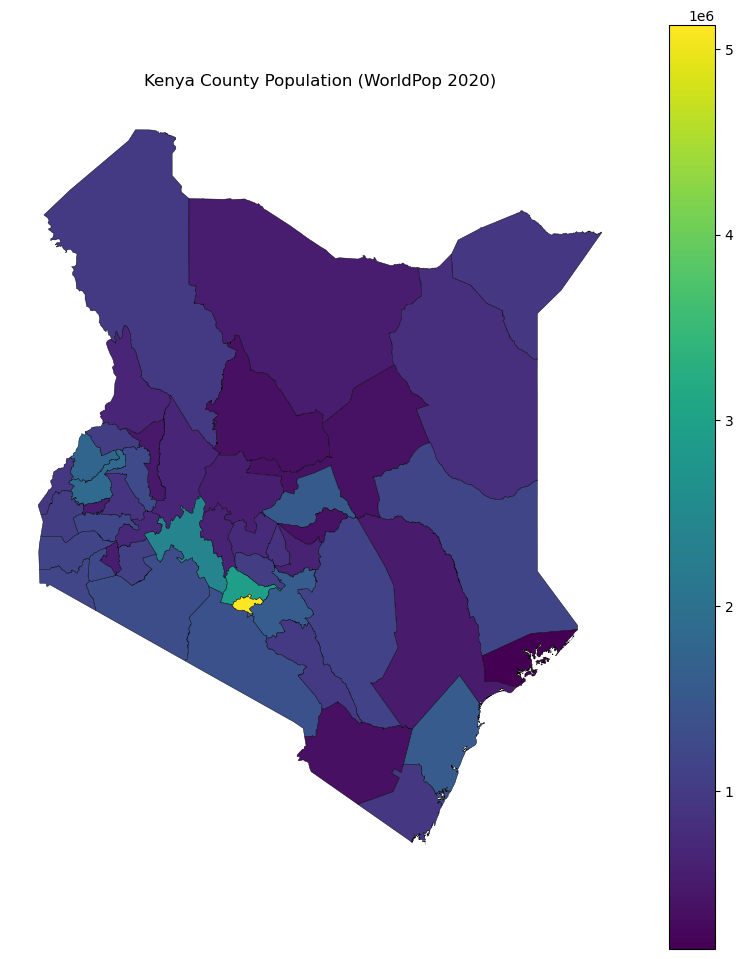

In [6]:

#Plot Kenya population map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 12))

gdf_pop.plot(
    column="population",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_title("Kenya County Population (WorldPop 2020)")
ax.axis("off")

plt.show()

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from pathlib import Path
import matplotlib as mpl


synthetic_kenya_malaria_analytic_dataset.csv is a simulated dataset created to:

mimic malaria surveillance data embed underreporting allow testing of your correction method

It contains:

observed cases
corrected cases
reporting probability
climate proxies
spatial indices

In [14]:
#### 

import numpy as np
import pandas as pd
from pathlib import Path

np.random.seed(42)

BASE_DIR = Path(r"C:\Users\Tosin\Desktop\Malaria\Kenya")
BASE_DIR.mkdir(exist_ok=True, parents=True)

OUTPUT_FILE = BASE_DIR / "synthetic_kenya_malaria_analytic_dataset.csv"

nx, ny = 10, 10
dates = pd.date_range("2015-01-01", "2023-12-01", freq="MS")

space = []

for y in range(ny):
    for x in range(nx):
        idx = y * nx + x

        if x < 4 and y > 4:
            region = "lake_endemic"
        elif x > 6 and y < 4:
            region = "coastal"
        elif y > 7:
            region = "highland_low_risk"
        else:
            region = "seasonal_transition"

        space.append(
            {
                "subcounty_id": f"SC{idx + 1:03d}",
                "x": x,
                "y": y,
                "region": region
            }
        )

space_df = pd.DataFrame(space)

x = space_df["x"].values
y = space_df["y"].values

lake_hotspot = np.exp(
    -((x - 1.5) ** 2 / 9 + (y - 7.0) ** 2 / 7)
)

coastal_hotspot = 0.55 * np.exp(
    -((x - 8.0) ** 2 / 5 + (y - 1.5) ** 2 / 6)
)

background = 0.08 + 0.04 * np.random.normal(size=len(space_df))

pfpr_base = np.clip(
    0.02 + 0.42 * lake_hotspot + 0.18 * coastal_hotspot + background,
    0.005,
    0.65
)

population = np.random.lognormal(
    mean=11.2,
    sigma=0.35,
    size=len(space_df)
).astype(int)

population = np.clip(population, 30000, 180000)

facility_density = np.clip(
    2.2 + 0.35 * x - 0.18 * y + np.random.normal(0, 0.45, len(space_df)),
    0.4,
    7.0
)

travel_time = np.clip(
    120 - 10 * facility_density + 7.5 * y + np.random.normal(0, 12, len(space_df)),
    20,
    240
)

space_df["pfpr_base"] = pfpr_base
space_df["population"] = population
space_df["facility_density"] = facility_density
space_df["travel_time"] = travel_time

rows = []

for date in dates:
    month = date.month

    rainfall_season = 1.0 + 0.55 * np.sin(2 * np.pi * (month - 3) / 12)
    temp_season = 1.0 + 0.25 * np.sin(2 * np.pi * (month - 1) / 12)

    trend = 1.0 - 0.025 * (date.year - 2015)

    if date.year >= 2021:
        trend = trend + 0.035 * (date.year - 2020)

    trend = np.clip(trend, 0.72, 1.12)

    rainfall_mm = np.clip(
        85 * rainfall_season
        + 28 * lake_hotspot
        + np.random.normal(0, 18, len(space_df)),
        5,
        260
    )

    temperature_c = np.clip(
        23.5 * temp_season
        + 0.6 * coastal_hotspot
        - 0.7 * y / ny
        + np.random.normal(0, 0.9, len(space_df)),
        17,
        31
    )

    pfpr_t = np.clip(
        pfpr_base * (0.75 + 0.25 * rainfall_season) * trend,
        0.002,
        0.70
    )

    incidence_rate = (
        0.007
        + 0.085 * (pfpr_t ** 1.25)
        + 0.00010 * rainfall_mm
        + 0.0015 * np.maximum(temperature_c - 20, 0)
    )

    true_cases = np.random.poisson(
        np.clip(population * incidence_rate, 1, None)
    )

    ntd_reporting_coverage = np.clip(
        0.82
        - 0.0012 * travel_time
        + 0.035 * facility_density
        + np.random.normal(0, 0.04, len(space_df)),
        0.25,
        0.98
    )

    ntd_program_activity = np.clip(
        0.55
        + 0.25 * ntd_reporting_coverage
        + 0.08 * np.random.normal(size=len(space_df)),
        0.10,
        1.00
    )

    reporting_completeness = np.clip(
        0.62
        + 0.22 * ntd_reporting_coverage
        + 0.03 * facility_density
        - 0.0014 * travel_time
        + np.random.normal(0, 0.05, len(space_df)),
        0.20,
        0.99
    )

    reporting_timeliness = np.clip(
        0.58
        + 0.18 * ntd_program_activity
        + 0.02 * facility_density
        - 0.0012 * travel_time
        + np.random.normal(0, 0.06, len(space_df)),
        0.15,
        0.98
    )

    logit_p = (
        -0.45
        + 1.35 * (reporting_completeness - 0.65)
        + 1.00 * (reporting_timeliness - 0.60)
        + 0.35 * (facility_density - facility_density.mean()) / facility_density.std()
        - 0.55 * (travel_time - travel_time.mean()) / travel_time.std()
        + 0.65 * (ntd_reporting_coverage - 0.70)
        + np.random.normal(0, 0.18, len(space_df))
    )

    true_reporting_probability = 1 / (1 + np.exp(-logit_p))
    true_reporting_probability = np.clip(true_reporting_probability, 0.12, 0.96)

    observed_cases = np.random.poisson(
        true_reporting_probability * true_cases
    )

    for i in range(len(space_df)):
        rows.append(
            {
                "subcounty_id": space_df.loc[i, "subcounty_id"],
                "x": int(space_df.loc[i, "x"]),
                "y": int(space_df.loc[i, "y"]),
                "region": space_df.loc[i, "region"],
                "date": date,
                "year": date.year,
                "month": date.month,
                "population": int(population[i]),
                "pfpr": pfpr_t[i],
                "rainfall_mm": rainfall_mm[i],
                "temperature_c": temperature_c[i],
                "facility_density": facility_density[i],
                "travel_time": travel_time[i],
                "ntd_reporting_coverage": ntd_reporting_coverage[i],
                "ntd_program_activity": ntd_program_activity[i],
                "reporting_completeness": reporting_completeness[i],
                "reporting_timeliness": reporting_timeliness[i],
                "true_cases": true_cases[i],
                "true_reporting_probability": true_reporting_probability[i],
                "observed_cases": observed_cases[i]
            }
        )

df = pd.DataFrame(rows)


def zscore(series):
    return (series - series.mean()) / series.std()


for col in [
    "facility_density",
    "travel_time",
    "ntd_reporting_coverage",
    "ntd_program_activity"
]:
    df[col + "_z"] = zscore(df[col])


estimated_logit = (
    -0.50
    + 1.20 * (df["reporting_completeness"] - 0.65)
    + 0.90 * (df["reporting_timeliness"] - 0.60)
    + 0.30 * df["facility_density_z"]
    - 0.45 * df["travel_time_z"]
    + 0.55 * (df["ntd_reporting_coverage"] - 0.70)
    + 0.25 * (df["ntd_program_activity"] - 0.65)
)

df["estimated_reporting_probability"] = 1 / (1 + np.exp(-estimated_logit))
df["estimated_reporting_probability"] = df["estimated_reporting_probability"].clip(0.10, 0.98)

df["corrected_cases"] = df["observed_cases"] / df["estimated_reporting_probability"]

df["observed_incidence_per_1000"] = (
    1000 * df["observed_cases"] / df["population"]
)

df["corrected_incidence_per_1000"] = (
    1000 * df["corrected_cases"] / df["population"]
)

df["true_incidence_per_1000"] = (
    1000 * df["true_cases"] / df["population"]
)

df["correction_ratio"] = (
    df["corrected_cases"] / np.maximum(df["observed_cases"], 1)
)

df.to_csv(OUTPUT_FILE, index=False)

print("Synthetic malaria analytic dataset created.")
print("File saved to")
print(OUTPUT_FILE)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())

Synthetic malaria analytic dataset created.
File saved to
C:\Users\Tosin\Desktop\Malaria\Kenya\synthetic_kenya_malaria_analytic_dataset.csv
Rows: 10800
Columns: 30
  subcounty_id  x  y               region       date  year  month  population  \
0        SC001  0  0  seasonal_transition 2015-01-01  2015      1       44561   
1        SC002  1  0  seasonal_transition 2015-01-01  2015      1       63118   
2        SC003  2  0  seasonal_transition 2015-01-01  2015      1       64864   
3        SC004  3  0  seasonal_transition 2015-01-01  2015      1       55226   
4        SC005  4  0  seasonal_transition 2015-01-01  2015      1       69116   

       pfpr  rainfall_mm  ...  facility_density_z  travel_time_z  \
0  0.105858    15.833499  ...           -0.500410      -1.238346   
1  0.083552    33.749395  ...           -0.151368      -1.276399   
2  0.111288    44.632532  ...            0.311297      -0.961162   
3  0.142426    45.378848  ...            0.577686      -1.121718   
4  0.0824

In [15]:
np.random.seed(42)

BASE_DIR = Path(r"C:\Users\Tosin\Desktop\Malaria\Kenya")

GEOJSON_PATH = BASE_DIR / "geoBoundaries-KEN-ADM1.geojson"
ANALYTIC_DATA_PATH = BASE_DIR / "synthetic_kenya_malaria_analytic_dataset.csv"

OUTPUT_DIR = BASE_DIR / "kenya_final_county_maps"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

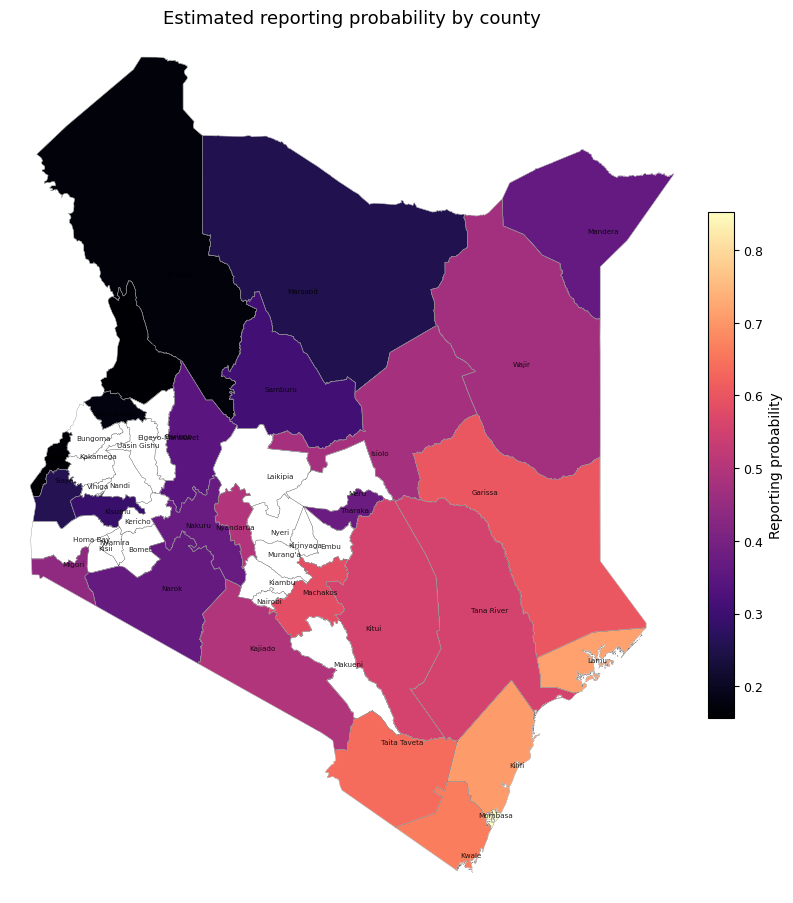

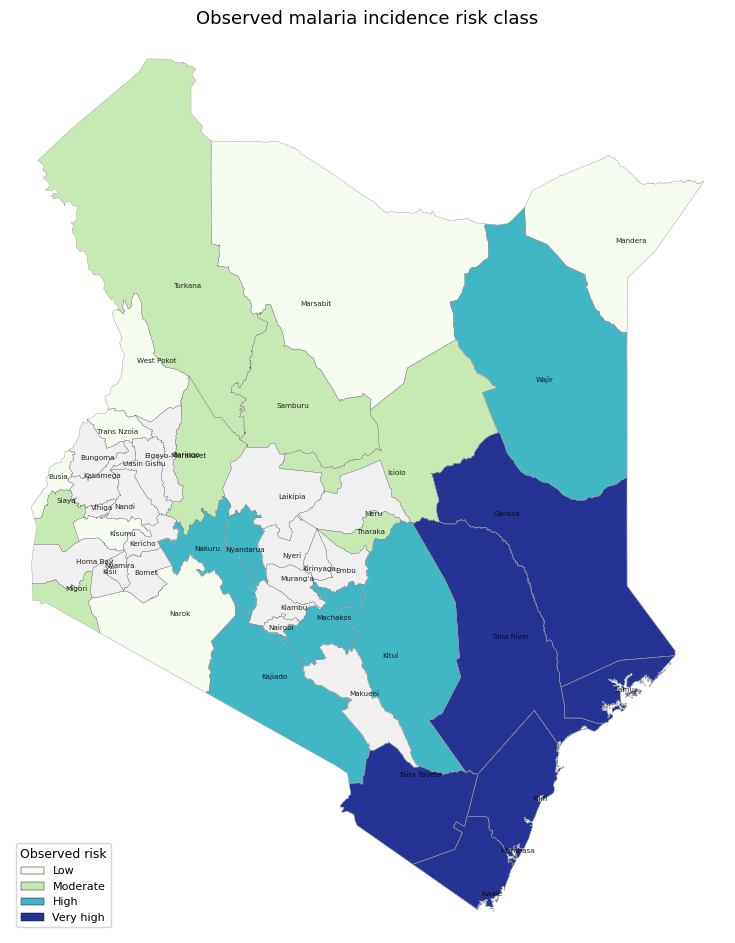

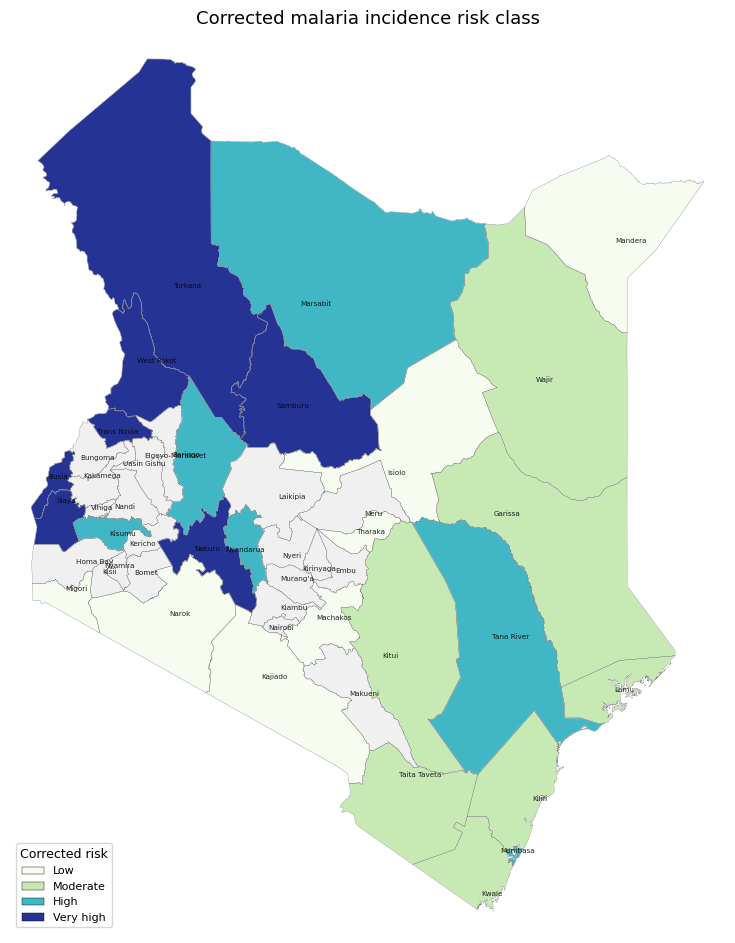

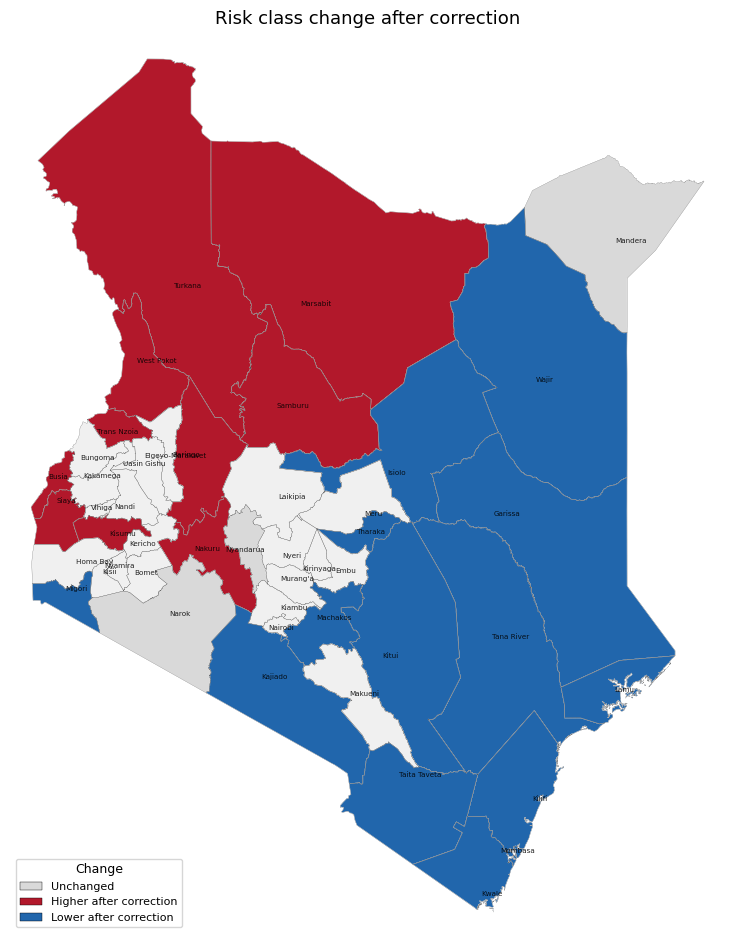

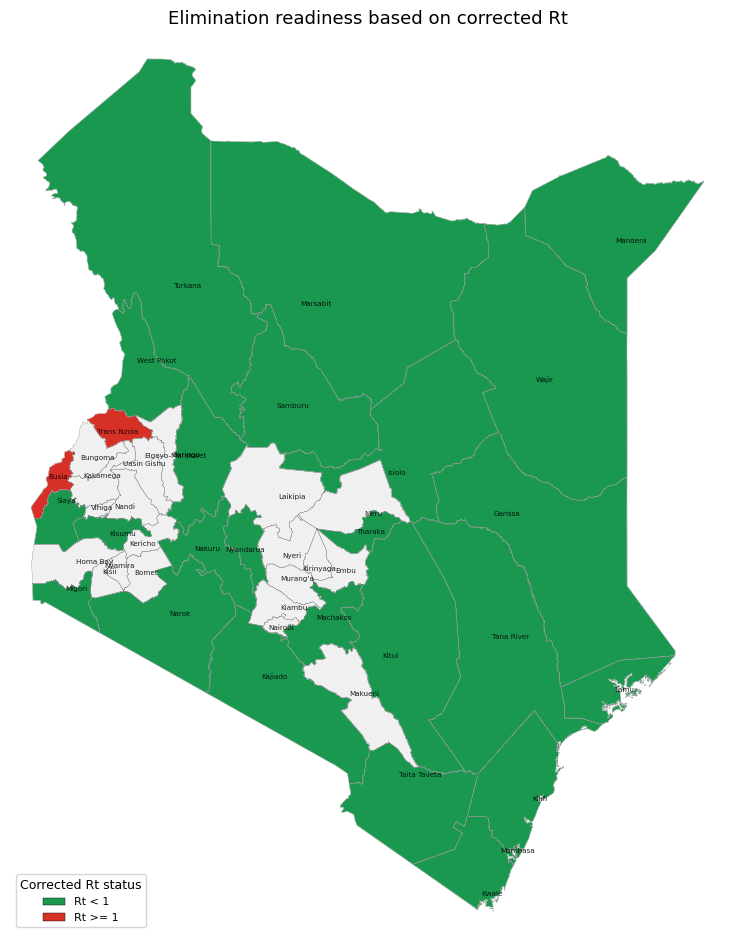

Finished generating county maps
Files saved in
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps\map1_reporting_probability_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps\map2_observed_risk_class_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps\map3_corrected_risk_class_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps\map4_risk_class_change_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps\map5_corrected_rt_status_with_county_names.png

Risk class change summary
misclassification
Lower after correction     14
Higher after correction    10
Unchanged                   3
Name: count, dtype: int64

Corrected Rt status summary
corrected_elimination_status
Rt < 1     25
Rt >= 1     2
Name: count, dtype: int64


In [16]:

df = pd.read_csv(ANALYTIC_DATA_PATH, parse_dates=["date"])

latest_date = df["date"].max()
latest = df[df["date"] == latest_date].copy()


def estimate_rt(incidence, generation_interval):
    incidence = np.asarray(incidence, dtype=float)
    w = np.asarray(generation_interval, dtype=float)
    w = w / w.sum()

    rt = np.full(len(incidence), np.nan)

    for t in range(1, len(incidence)):
        max_lag = min(t, len(w))
        past = incidence[t - np.arange(1, max_lag + 1)]
        infectiousness = np.sum(past * w[:max_lag])

        if infectiousness > 0:
            rt[t] = incidence[t] / infectiousness

    return rt


generation_interval = np.array([0.25, 0.35, 0.25, 0.10, 0.05])

rt_rows = []

for sid, g in df.groupby("subcounty_id"):
    g = g.sort_values("date").copy()
    g["Rt_observed"] = estimate_rt(g["observed_cases"].values, generation_interval)
    g["Rt_corrected"] = estimate_rt(g["corrected_cases"].values, generation_interval)
    rt_rows.append(g[["subcounty_id", "date", "Rt_observed", "Rt_corrected"]])

rt_df = pd.concat(rt_rows, ignore_index=True)

latest = latest.merge(
    rt_df[rt_df["date"] == latest_date][["subcounty_id", "Rt_observed", "Rt_corrected"]],
    on="subcounty_id",
    how="left"
)


with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    geo = json.load(f)


def get_county_name(properties):
    possible_keys = [
        "shapeName",
        "ADM1_EN",
        "NAME_1",
        "name",
        "County",
        "county"
    ]

    for key in possible_keys:
        if key in properties and properties[key] is not None:
            return str(properties[key])

    return str(properties)


def polygon_rings_from_geometry(geometry):
    rings = []

    if geometry["type"] == "Polygon":
        if len(geometry["coordinates"]) > 0:
            rings.append(np.asarray(geometry["coordinates"][0], dtype=float))

    elif geometry["type"] == "MultiPolygon":
        for polygon in geometry["coordinates"]:
            if len(polygon) > 0:
                rings.append(np.asarray(polygon[0], dtype=float))

    return rings


counties = []

for feature in geo["features"]:
    rings = polygon_rings_from_geometry(feature["geometry"])

    if rings:
        counties.append(
            {
                "name": get_county_name(feature["properties"]),
                "rings": rings
            }
        )


all_coords = np.vstack([ring for county in counties for ring in county["rings"]])

lon_min, lat_min = all_coords.min(axis=0)
lon_max, lat_max = all_coords.max(axis=0)


for county in counties:
    county["paths"] = [MplPath(ring[:, :2]) for ring in county["rings"]]


def point_county(lon, lat):
    for county in counties:
        for path in county["paths"]:
            if path.contains_point((lon, lat)):
                return county["name"]

    return None


county_centroids = []

for county in counties:
    largest_ring = max(county["rings"], key=lambda ring: len(ring))
    centroid = largest_ring.mean(axis=0)

    county_centroids.append(
        {
            "county_name": county["name"],
            "centroid_lon": centroid[0],
            "centroid_lat": centroid[1]
        }
    )

county_centroids = pd.DataFrame(county_centroids)


spatial = latest[["subcounty_id", "x", "y"]].drop_duplicates().copy()

spatial["lon_raw"] = (
    lon_min
    + (spatial["x"] - spatial["x"].min())
    / (spatial["x"].max() - spatial["x"].min())
    * (lon_max - lon_min)
)

spatial["lat_raw"] = (
    lat_min
    + (spatial["y"] - spatial["y"].min())
    / (spatial["y"].max() - spatial["y"].min())
    * (lat_max - lat_min)
)


assigned_counties = []

for _, row in spatial.iterrows():
    lon = row["lon_raw"]
    lat = row["lat_raw"]

    county = point_county(lon, lat)

    if county is None:
        distance = (
            (county_centroids["centroid_lon"] - lon) ** 2
            + (county_centroids["centroid_lat"] - lat) ** 2
        )

        county = county_centroids.loc[distance.idxmin(), "county_name"]

    assigned_counties.append(county)

spatial["county_name"] = assigned_counties


latest2 = latest.drop(columns=["county_name"], errors="ignore").merge(
    spatial[["subcounty_id", "county_name"]],
    on="subcounty_id",
    how="left"
)


def risk_class_from_quantiles(series):
    q1, q2, q3 = np.quantile(series, [0.25, 0.50, 0.75])

    return pd.cut(
        series,
        bins=[-np.inf, q1, q2, q3, np.inf],
        labels=["Low", "Moderate", "High", "Very high"],
        include_lowest=True
    )


county_values = latest2.groupby("county_name").agg(
    estimated_reporting_probability=("estimated_reporting_probability", "mean"),
    observed_incidence_per_1000=("observed_incidence_per_1000", "mean"),
    corrected_incidence_per_1000=("corrected_incidence_per_1000", "mean"),
    Rt_corrected=("Rt_corrected", "mean"),
    n_units=("subcounty_id", "count")
).reset_index()


county_values["difference_corrected_observed"] = (
    county_values["corrected_incidence_per_1000"]
    - county_values["observed_incidence_per_1000"]
)

county_values["observed_risk_class"] = risk_class_from_quantiles(
    county_values["observed_incidence_per_1000"]
).astype(str)

county_values["corrected_risk_class"] = risk_class_from_quantiles(
    county_values["corrected_incidence_per_1000"]
).astype(str)


risk_num = {
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very high": 4
}

county_values["observed_risk_num"] = county_values["observed_risk_class"].map(risk_num)
county_values["corrected_risk_num"] = county_values["corrected_risk_class"].map(risk_num)

county_values["risk_shift"] = (
    county_values["corrected_risk_num"]
    - county_values["observed_risk_num"]
)

county_values["misclassification"] = np.where(
    county_values["risk_shift"] > 0,
    "Higher after correction",
    np.where(
        county_values["risk_shift"] < 0,
        "Lower after correction",
        "Unchanged"
    )
)

county_values["corrected_elimination_status"] = np.where(
    county_values["Rt_corrected"] < 1,
    "Rt < 1",
    "Rt >= 1"
)


county_values.to_csv(OUTPUT_DIR / "county_level_map_values.csv", index=False)
latest2.to_csv(OUTPUT_DIR / "latest_month_spatially_assigned_units.csv", index=False)

value_lookup = {
    row["county_name"]: row
    for _, row in county_values.iterrows()
}


mpl.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans"
    }
)


def add_boundaries(ax):
    for county in counties:
        for ring in county["rings"]:
            ax.plot(
                ring[:, 0],
                ring[:, 1],
                color="black",
                linewidth=0.18,
                alpha=0.65
            )


def format_map(ax):
    ax.set_xlim(lon_min - 0.25, lon_max + 0.25)
    ax.set_ylim(lat_min - 0.25, lat_max + 0.25)
    ax.set_aspect("equal")
    ax.axis("off")


def add_county_labels(ax):
    for _, row in county_centroids.iterrows():
        ax.text(
            row["centroid_lon"],
            row["centroid_lat"],
            row["county_name"],
            fontsize=5.2,
            ha="center",
            va="center",
            color="black",
            alpha=0.85
        )


def make_patches_values(column):
    patches = []
    values = []

    for county in counties:
        val = np.nan

        if county["name"] in value_lookup:
            val = value_lookup[county["name"]][column]

        for ring in county["rings"]:
            patches.append(MplPolygon(ring[:, :2], closed=True))
            values.append(val)

    return patches, np.asarray(values, dtype=float)


def plot_continuous(column, title, filename, label, cmap="magma"):
    patches, values = make_patches_values(column)

    fig, ax = plt.subplots(figsize=(8, 9.5))

    collection = PatchCollection(
        patches,
        cmap=cmap,
        linewidth=0.35,
        edgecolor="white"
    )

    collection.set_array(values)
    collection.set_clim(np.nanmin(values), np.nanmax(values))

    ax.add_collection(collection)

    add_boundaries(ax)
    add_county_labels(ax)
    format_map(ax)

    ax.set_title(title, pad=10)

    cbar = fig.colorbar(collection, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(label)

    plt.tight_layout()

    out = OUTPUT_DIR / filename
    plt.savefig(out, bbox_inches="tight", dpi=600)
    plt.show()

    return out


def plot_categorical(column, title, filename, color_map, legend_title):
    fig, ax = plt.subplots(figsize=(8, 9.5))

    for county in counties:
        val = None

        if county["name"] in value_lookup:
            val = value_lookup[county["name"]][column]

        facecolor = color_map.get(val, "#F0F0F0")

        for ring in county["rings"]:
            patch = MplPolygon(
                ring[:, :2],
                closed=True,
                facecolor=facecolor,
                edgecolor="white",
                linewidth=0.35
            )

            ax.add_patch(patch)

    add_boundaries(ax)
    add_county_labels(ax)
    format_map(ax)

    ax.set_title(title, pad=10)

    handles = [
        mpl.patches.Patch(
            facecolor=value,
            edgecolor="black",
            linewidth=0.3,
            label=key
        )
        for key, value in color_map.items()
    ]

    ax.legend(
        handles=handles,
        title=legend_title,
        loc="lower left",
        frameon=True,
        fontsize=8,
        title_fontsize=9
    )

    plt.tight_layout()

    out = OUTPUT_DIR / filename
    plt.savefig(out, bbox_inches="tight", dpi=600)
    plt.show()

    return out


risk_colors = {
    "Low": "#F7FCF0",
    "Moderate": "#C7E9B4",
    "High": "#41B6C4",
    "Very high": "#253494"
}

misclassification_colors = {
    "Unchanged": "#D9D9D9",
    "Higher after correction": "#B2182B",
    "Lower after correction": "#2166AC"
}

rt_colors = {
    "Rt < 1": "#1A9850",
    "Rt >= 1": "#D73027"
}


map_files = []

map_files.append(
    plot_continuous(
        column="estimated_reporting_probability",
        #title="Estimated reporting probability by county",
        filename="map1_reporting_probability_with_county_names.png",
        label="Reporting probability",
        cmap="magma"
    )
)

map_files.append(
    plot_categorical(
        column="observed_risk_class",
        #title="Observed malaria incidence risk class",
        filename="map2_observed_risk_class_with_county_names.png",
        color_map=risk_colors,
        legend_title="Observed risk"
    )
)

map_files.append(
    plot_categorical(
        column="corrected_risk_class",
        #title="Corrected malaria incidence risk class",
        filename="map3_corrected_risk_class_with_county_names.png",
        color_map=risk_colors,
        legend_title="Corrected risk"
    )
)

map_files.append(
    plot_categorical(
        column="misclassification",
        #title="Risk class change after correction",
        filename="map4_risk_class_change_with_county_names.png",
        color_map=misclassification_colors,
        legend_title="Change"
    )
)

map_files.append(
    plot_categorical(
        column="corrected_elimination_status",
        #title="Elimination readiness based on corrected Rt",
        filename="map5_corrected_rt_status_with_county_names.png",
        color_map=rt_colors,
        legend_title="Corrected Rt status"
    )
)


print("Finished generating county maps")
print("Files saved in")
print(OUTPUT_DIR)

for file in map_files:
    print(file)

print("\nRisk class change summary")
print(county_values["misclassification"].value_counts())

print("\nCorrected Rt status summary")
print(county_values["corrected_elimination_status"].value_counts())

In [ ]:
#1. Observed, corrected and laent malaria incidence- time series
#2. Estimated reporting probability in the latest month (you need to explain what latest month means)- heat map
#3. Observed malaria incidence per 1000 population- heat map
#4. Corrected malaria incidence per 1000 population-heat map
#5. Distribution of incidence correction ratios (histogram)
#6. Reproduction number from observed and corrected incidence (corrected incidence and observed incidence appear to have the same trend- clearly explain why)-time series
#7. Elimination readiness classification shift-bar chart
#8. covariate effects on stimated rporting probability - bar chart
#9. Estimated reporting prbability by county - Map
#10. Observed malaria incidence risk class- Map
#11. Corrected Malaria incdence risk class - Map
#12. Risk class range aftrr correction-Map
#13. Elimination readiness base on corrected Rt - Map
